## Importing dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# https://www.kaggle.com/datasets/brijbhushannanda1979/bigmart-sales-data
mart_df_train = pd.read_csv('train.csv')
mart_df_test = pd.read_csv('test.csv')
mart_df_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
mart_df_test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [4]:
mart_df_train.shape

(8523, 12)

In [5]:
mart_df_test.shape

(5681, 11)

In [6]:
mart_df_train.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [7]:
mart_df_test.isna().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [8]:
mart_df_train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [9]:
mart_df_test.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4705.000000,5681.000000,5681.000000,5681.000000
mean,12.695633,0.065684,141.023273,1997.828903
std,4.664849,0.051252,61.809091,8.372256
min,4.555000,0.000000,31.990000,1985.000000
25%,8.645000,0.027047,94.412000,1987.000000
50%,12.500000,0.054154,141.415400,1999.000000
75%,16.700000,0.093463,186.026600,2004.000000
max,21.350000,0.323637,266.588400,2009.000000


## Filling missing values

In [10]:
# For Item_Weight column
mart_df_train['Item_Weight'] = mart_df_train['Item_Weight'].fillna(mart_df_train['Item_Weight'].mean()) # for train data
mart_df_test['Item_Weight'] = mart_df_test['Item_Weight'].fillna(mart_df_test['Item_Weight'].mean()) # for test data

In [11]:
# For Outlet_Size column - train data
mode_of_outlet_size = mart_df_train.pivot_table(values="Outlet_Size", columns = "Outlet_Type", aggfunc=(lambda x : x.mode()[0]))
mode_of_outlet_size

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [12]:
mode_map = {
    'Grocery Store': 'Small',
    'Supermarket Type1': 'Small',
    'Supermarket Type2': 'Medium',
    'Supermarket Type3': 'Medium'
}

# fill missing Outlet_Size based on Outlet_Type - train data
mart_df_train['Outlet_Size'] = mart_df_train['Outlet_Size'].fillna(mart_df_train['Outlet_Type'].map(mode_map))

In [13]:
# Filling missing values based on outlet type - train data
# missing_vals = mart_df_train['Outlet_Size'].isnull()
# mart_df_train.loc[missing_vals, 'Outlet_Size'] = mart_df_train.loc[missing_vals, 'Outlet_Type'].apply(lambda x: mode_of_outlet_size)

In [14]:
# For Outlet_Size column - Test Data
mode_of_outlet_size_test = mart_df_test.pivot_table(values="Outlet_Size", columns = "Outlet_Type", aggfunc=(lambda x : x.mode()[0]))
mode_of_outlet_size_test

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [15]:
mode_map = {
    'Grocery Store': 'Small',
    'Supermarket Type1': 'Small',
    'Supermarket Type2': 'Medium',
    'Supermarket Type3': 'Medium'
}

# fill missing Outlet_Size based on Outlet_Type - train data
mart_df_test['Outlet_Size'] = mart_df_test['Outlet_Size'].fillna(mart_df_test['Outlet_Type'].map(mode_map))

In [16]:
# Filling missing values based on outlet type - test data
# missing_vals = mart_df_test['Outlet_Size'].isnull()
# mart_df_test.loc[missing_vals, 'Outlet_Size'] = mart_df_test.loc[missing_vals, 'Outlet_Type'].apply(lambda x: mode_of_outlet_size_test)

In [17]:
mart_df_train.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [18]:
mart_df_test.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

#### Numerical features

In [19]:
sns.set()

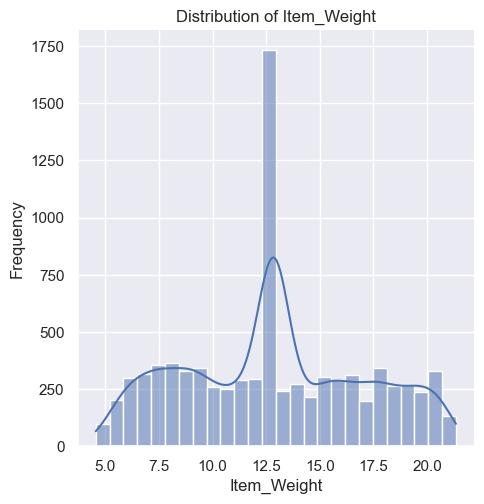

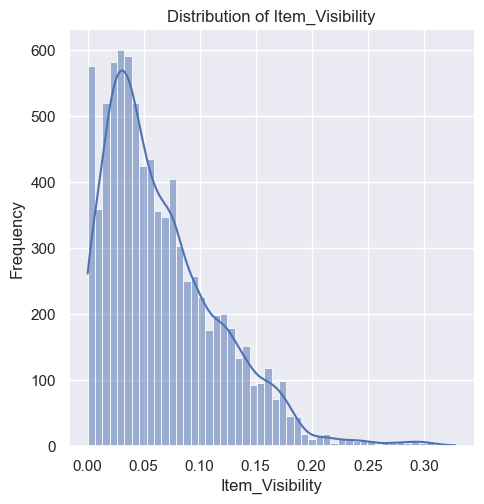

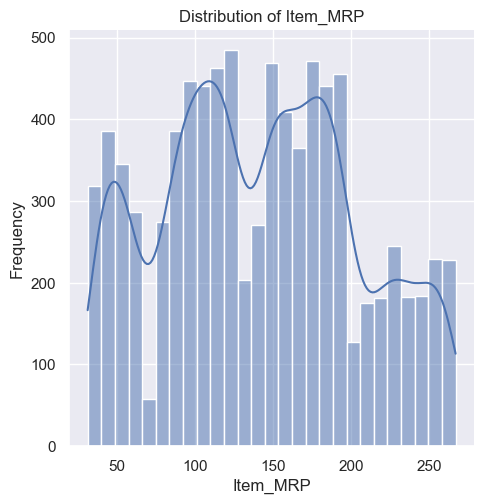

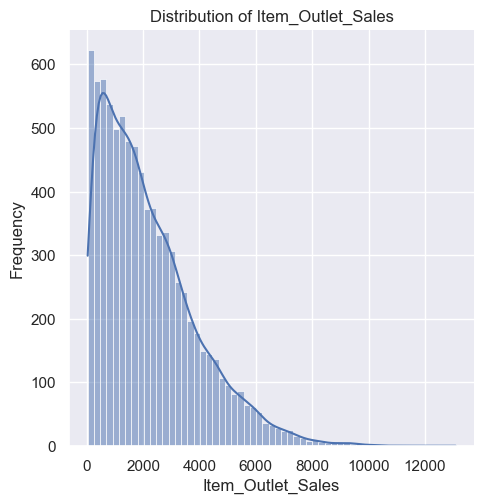

In [20]:
cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']

for col in cols:
    sns.displot(mart_df_train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

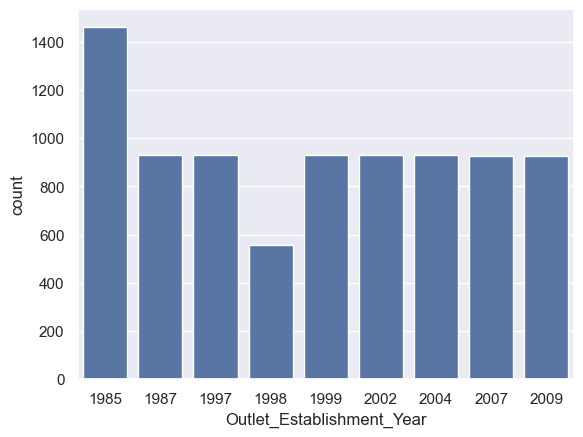

In [21]:
# For Outlet_Establishment_Year
sns.countplot(x='Outlet_Establishment_Year', data=mart_df_train)
plt.show()

#### Categorical features

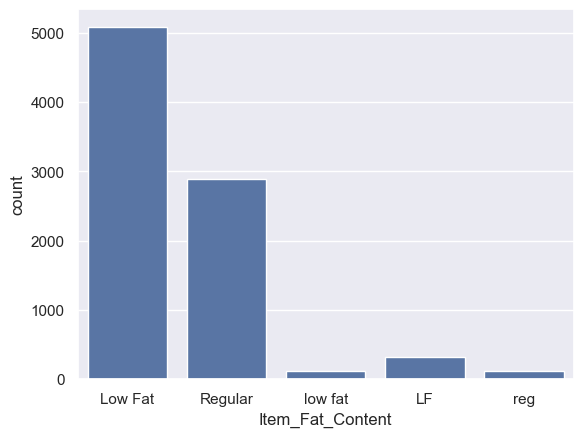

In [22]:
# Item_Fat_Content - Train data
sns.countplot(x='Item_Fat_Content', data=mart_df_train)
plt.show()

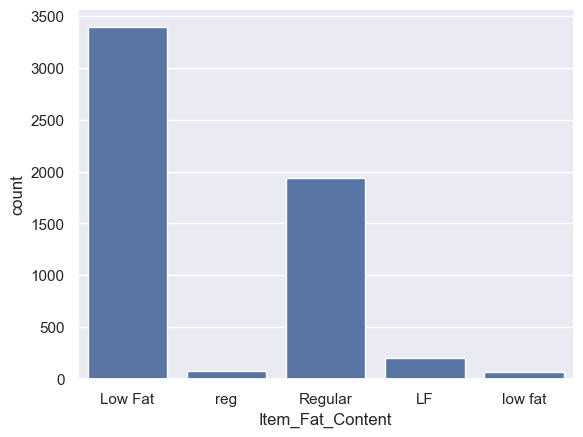

In [23]:
# Item_Fat_Content - Test data
sns.countplot(x='Item_Fat_Content', data=mart_df_test)
plt.show()

C:\Users\manus\AppData\Local\Temp\ipykernel_10008\983318734.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90, ha="right")


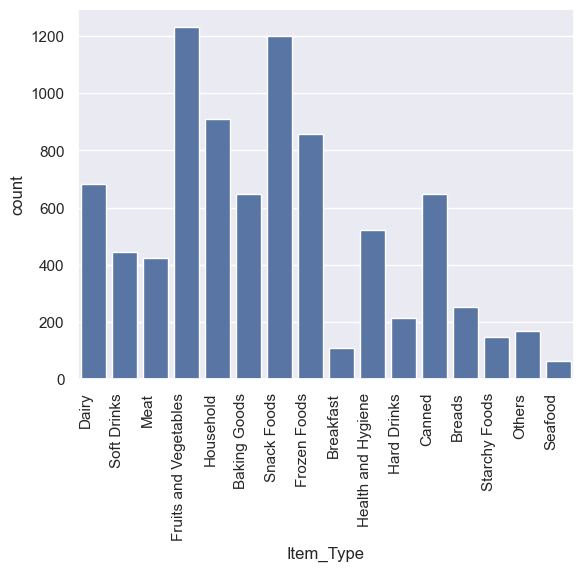

In [24]:
# Item Type - Train data
g = sns.countplot(x='Item_Type', data=mart_df_train)
g.set_xticklabels(g.get_xticklabels(), rotation=90, ha="right")
plt.show()

C:\Users\manus\AppData\Local\Temp\ipykernel_10008\1851623094.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90, ha="right")


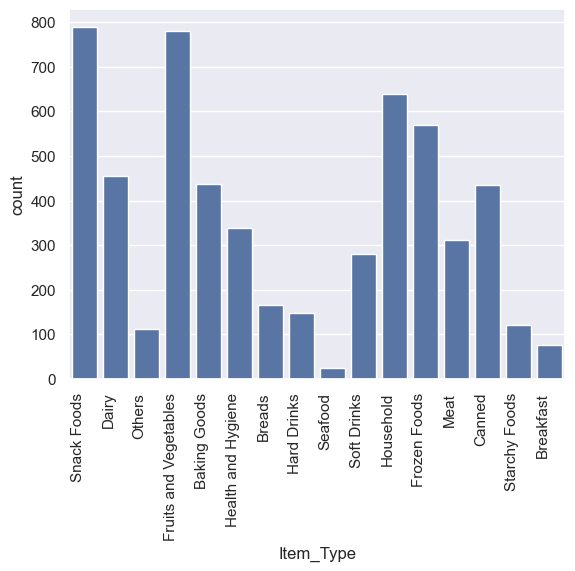

In [25]:
# Item Type - Test data
g = sns.countplot(x='Item_Type', data=mart_df_test)
g.set_xticklabels(g.get_xticklabels(), rotation=90, ha="right")
plt.show()

In [26]:
mart_df_train['Outlet_Size'].value_counts()

Outlet_Size
Small     4798
Medium    2793
High       932
Name: count, dtype: int64

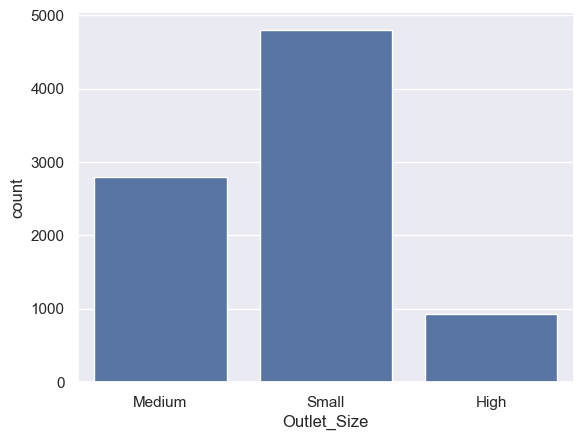

In [27]:
# Outlet_Size - Train
sns.countplot(x='Outlet_Size', data=mart_df_train)
plt.show()

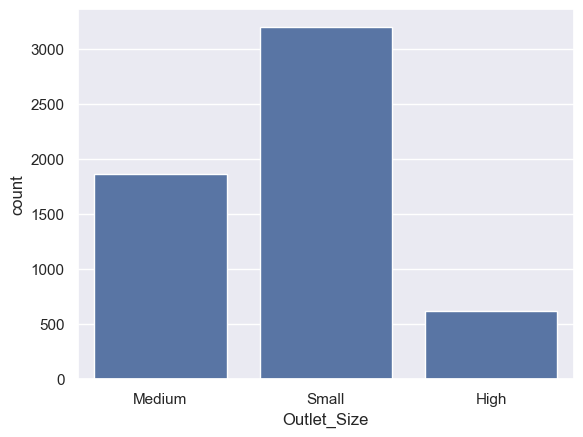

In [28]:
# Outlet_Size - Test
sns.countplot(x='Outlet_Size', data=mart_df_test)
plt.show()

#### Data Preprocessing

In [29]:
mart_df_train.head(3)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700


In [30]:
mart_df_train['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [31]:
mart_df_train['Item_Fat_Content'] = mart_df_train['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'regular': 'Regular',
    'reg': 'Regular'
}).fillna('Unknown')


In [32]:
mart_df_train['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [33]:
mart_df_train['Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

In [34]:
mart_df_train['Outlet_Type'].value_counts()

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

In [35]:
mart_df_test['Item_Fat_Content'] = mart_df_test['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'regular': 'Regular',
    'reg': 'Regular'
}).fillna('Unknown')

In [36]:
print(mart_df_test['Item_Fat_Content'].value_counts())

print(mart_df_test['Outlet_Type'].value_counts())

print(mart_df_test['Outlet_Location_Type'].value_counts())

Item_Fat_Content
Low Fat    3668
Regular    2013
Name: count, dtype: int64
Outlet_Type
Supermarket Type1    3717
Grocery Store         722
Supermarket Type3     624
Supermarket Type2     618
Name: count, dtype: int64
Outlet_Location_Type
Tier 3    2233
Tier 2    1856
Tier 1    1592
Name: count, dtype: int64


#### label Encoding

In [37]:
test_ids = mart_df_test[['Item_Identifier', 'Outlet_Identifier']].copy()

In [38]:
encoder = LabelEncoder()

In [39]:
cat_cols = [
    'Item_Fat_Content', 'Item_Type',
    'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'
]

for col in cat_cols:
    combined_data = pd.concat([mart_df_train[col], mart_df_test[col]], axis=0)
    encoder.fit(combined_data)
    mart_df_train[col] = encoder.transform(mart_df_train[col])
    mart_df_test[col] = encoder.transform(mart_df_test[col])

In [40]:
mart_df_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,DRC01,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,FDN15,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,FDX07,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,NCD19,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [41]:
mart_df_train['Outlet_Identifier'] = mart_df_train['Outlet_Identifier'].astype('category')
mart_df_test['Outlet_Identifier'] = mart_df_test['Outlet_Identifier'].astype('category')

In [42]:
## Splitting the data into features and labels
X = mart_df_train.drop(columns=['Item_Outlet_Sales','Item_Identifier'], axis=1)
Y = mart_df_train['Item_Outlet_Sales']

In [43]:
## Training and testing data
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

#### Model Training

In [44]:
regressor = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    enable_categorical=True  # 
)

In [45]:
regressor.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [46]:
# Prediction on training data
train_pred = regressor.predict(X_train)

In [47]:
#  Evaluate the model
r2 = r2_score(y_train, train_pred)
rmse = mean_squared_error(y_train, train_pred, squared=False)
print("R2:", r2)
print("RMSE:", rmse)

R2: 0.8703803958405515
RMSE: 619.2102233172939


D:\Program Files\anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [48]:
# Prediction on test data
test_predict = regressor.predict(X_test)

# Evaluation
print("R2:", r2_score(y_test, test_predict))
print("RMSE:", mean_squared_error(y_test, test_predict, squared=False))

R2: 0.5698907907031026
RMSE: 1081.214112118943


D:\Program Files\anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [49]:
mart_df_test = mart_df_test.drop(columns=['Item_Identifier'], axis=1)

In [50]:
# Predict on the external test data
test_predictions = regressor.predict(mart_df_test)

In [51]:
submission = pd.DataFrame({
    'Item_Identifier': test_ids['Item_Identifier'],
    'Outlet_Identifier': test_ids['Outlet_Identifier'],
    'Item_Outlet_Sales': test_predictions
})
submission.to_csv("submission.csv", index=False)

In [52]:
submission_df = pd.read_csv('submission.csv')
submission_df.head()

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1261.5076
1,FDW14,OUT017,1145.4870
2,NCN55,OUT010,464.6409
3,FDQ58,OUT017,2096.7320
4,FDY38,OUT027,6117.2393
